<a href="https://colab.research.google.com/github/rinermdhn/Twitter-Analytics---Beasiswa-Putri-Ariani/blob/main/Twitter_Analytics_Beasiswa_Putri_Ariani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Modul

In [ ]:
!pip install Sastrawi
import os
import datetime
import pandas as pd
import ast
import json

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import warnings; warnings.simplefilter('ignore')
import nltk

try:
    import google.colab
    IN_COLAB = True
    !wget https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/taudataDDGsna.py
    !mkdir data
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/contoh.pdf
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/slang.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/stopwords_id.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/stopwords_en.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/kata_dasar.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/wn-ind-def.tab
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/wn-msa-all.tab
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/ind_SA.csv
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/all_indo_man_tag_corpus_model.crf.tagger

    !pip install --upgrade spacy python-crfsuite unidecode textblob sastrawi sklearn-pycrfsuite
    !pip install --upgrade unidecode twython tweepy beautifulsoup4 tika
    !python -m spacy download en
    !python -m spacy download xx
    !python -m spacy download en_core_web_sm
    nltk.download('popular')
except:
    IN_COLAB = False
    print("Running the code locally, please make sure all the python module versions agree with colab environment and all data/assets downloaded")

--2023-06-21 04:41:43--  https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/taudataDDGsna.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8030 (7.8K) [text/plain]
Saving to: ‘taudataDDGsna.py’

taudataDDGsna.py    100%[===================>]   7.84K  --.-KB/s    in 0s      

2023-06-21 04:41:44 (49.0 MB/s) - ‘taudataDDGsna.py’ saved [8030/8030]

--2023-06-21 04:41:44--  https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/contoh.pdf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 221233 (21

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

In [ ]:
import taudataDDGsna as tau
from bs4 import BeautifulSoup as bs
from tqdm import tqdm
"Done"

'Done'

In [ ]:
!pip3 install git+https://github.com/JustAnotherArchivist/snscrape.git

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/JustAnotherArchivist/snscrape.git to /tmp/pip-req-build-n52lqa5f
  Running command git clone --filter=blob:none --quiet https://github.com/JustAnotherArchivist/snscrape.git /tmp/pip-req-build-n52lqa5f
  Resolved https://github.com/JustAnotherArchivist/snscrape.git to commit 0d824ab77334ed4ab6250e5e491171afeccfb298
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for snscrape: filename=snscrape-0.6.2.20230321.dev50+g0d824ab-py3-none-any.whl size=74426 sha256=fe25c0b9b872cc838729a23ec0cf3e25d88fe4b917493bbca0713414594c0496
  Stored in directory: /tmp/pip-ephem-wheel-cache-j1k9nh4w/wheels/05/e9/f7/57056e7c7e44b1feed932fa49fdec9d706c4f563e37160ab74
Successfully built snscrape


# Pre-Processing Data

In [ ]:
# Batasi jumlah hasil yang diambil
max_results = 1000

# Gunakan Twitter search untuk mencari tweet yang di-favoritkan minimal 10000 kali dan berbahasa Indonesia
twitter_search = "beasiswa ariani lang:id since:2023-01-01 until:2023-06-19"

# Tentukan nama file dengan format "<kueri pencarian>_<tanggal saat ini>.json"
filename = f"{twitter_search.replace(' ', '_').replace(':', '-').replace('#', '')}_{datetime.date.today().strftime('%Y-%m-%d')}.json"

USING_TOP_SEARCH = False

snscrape_params = '--jsonl --max-results'
twitter_search_params = ''

if USING_TOP_SEARCH:
    twitter_search_params += "--top"

snscrape_search_query = f"snscrape {snscrape_params} {max_results} twitter-search {twitter_search_params} '{twitter_search}' > {filename}"

print(snscrape_search_query)

os.system(snscrape_search_query)

snscrape --jsonl --max-results 1000 twitter-search  'beasiswa ariani lang:id since:2023-01-01 until:2023-06-19' > beasiswa_ariani_lang-id_since-2023-01-01_until-2023-06-19_2023-06-21.json


0

In [ ]:
# Membuat dataframe pandas
tweets_df = pd.read_json(filename, lines=True)

NAMA_FILE_CSV = 'beasiswa_ariani.csv'

# Membuat kamus untuk mengganti nama kolom
new_columns = {
    'conversationId': 'Conv. ID',
    'url': 'URL',
    'date': 'Date',
    'rawContent': 'Tweet',
    'id': 'ID',
    'replyCount': 'Replies',
    'retweetCount': 'Retweets',
    'likeCount': 'Likes',
    'quoteCount': 'Quotes',
    'bookmarkCount': 'Bookmarks',
    'lang': 'Language',
    'links': 'Links',
    'media': 'Media',
    'retweetedTweet': 'Retweeted Tweet',
    'username': 'Username'
}

if len(tweets_df) == 0:
    print('Pencarian tidak ditemukan coba ganti keyword lain, keywordmu: ', twitter_search)
    exit()
else:
  # Memilih kolom yang akan digunakan dan mengganti nama kolom menggunakan kamus yang telah dibuat
  tweets_df = tweets_df.loc[:, ['url', 'date', 'rawContent', 'id',
                            'replyCount', 'retweetCount', 'likeCount', 'quoteCount',
                            'conversationId', 'lang', 'links',
                            'media', 'retweetedTweet', 'bookmarkCount', 'username']]
  tweets_df = tweets_df.rename(columns=new_columns)

  # Ekstrak fullUrl dari kolom media dan url dari kolom links
  tweets_df['Media'] = tweets_df['Media'].apply(lambda x: x[0]['fullUrl'] if isinstance(x, list) and x and isinstance(x[0], dict) and 'fullUrl' in x[0] else None)
  tweets_df['Links'] = tweets_df['Links'].apply(lambda x: x[0]['url'] if isinstance(x, list) and x and isinstance(x[0], dict) and 'url' in x[0] else None)

  # Menampilkan dataframe tweets_df
  display(tweets_df)

  # Simpan ke csv
  tweets_df.to_csv(NAMA_FILE_CSV, index=False)


,URL,Date,Tweet,ID,Replies,Retweets,Likes,Quotes,Conv. ID,Language,Links,Media,Retweeted Tweet,Bookmarks,Username
0,https://twitter.com/matamata_com/status/167042...,2023-06-18 13:22:03+00:00,Nadiem Makarim ungkap bakal kasih beasiswa unt...,1670421618588528640,0,0,0,0,1670421618588528640,in,https://www.matamata.com/seleb/2023/06/18/2015...,None,NaN,0,matamata_com
1,https://twitter.com/matamata_com/status/167036...,2023-06-18 09:36:04+00:00,Nadiem Makarim ungkap bakal kasih beasiswa unt...,1670364748377124869,0,0,0,0,1670364748377124869,in,https://glow.matamata.com/read/2023/06/18/1631...,None,NaN,0,matamata_com
2,https://twitter.com/cocor_bangor/status/166998...,2023-06-17 08:15:59+00:00,Disaat Kemendikbudristek sedang disoroti karen...,1669982206276825088,1,1,3,0,1669982196520861696,in,None,https://pbs.twimg.com/media/Fyz39l6acAEecDr?fo...,NaN,0,cocor_bangor
3,https://twitter.com/KompasTV/status/1669884327...,2023-06-17 01:47:03+00:00,"Usai Raih Golden Buzzer, Putri Ariani Dapat Be...",1669884327277232130,2,8,31,0,1669884327277232130,in,http://dlvr.it/SqpBvl,None,NaN,0,KompasTV
4,https://twitter.com/kompascom/status/166973837...,2023-06-16 16:07:06+00:00,Disdikpora Daerah Istimewa Yogyakarta (DIY) se...,1669738377246314496,1,0,2,1,1669738377246314496,in,http://dlvr.it/SqnF1z,None,NaN,0,kompascom
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,https://twitter.com/harihariheri/status/166704...,2023-06-09 05:45:44+00:00,#serunya dapet beasiswa LPDP itu mungkin ga t...,1667045291567239169,0,0,2,0,1667045291567239169,in,None,None,NaN,0,harihariheri
187,https://twitter.com/Mingfan35/status/166665691...,2023-06-08 04:02:28+00:00,@NKRI_jokowisyoo baguslah putri ariani dapat b...,1666656917882810370,1,0,23,0,1666637839877156865,in,None,None,NaN,0,Mingfan35
188,https://twitter.com/HestiBambang/status/166660...,2023-06-08 00:19:12+00:00,Presiden layak berikan apresiasi utk Putri Ari...,1666600730910945280,0,0,0,0,1666600730910945280,in,None,None,NaN,0,HestiBambang
189,https://twitter.com/ymzkyzru/status/1624717161...,2023-02-12 10:28:51+00:00,Ariani masuk jurusan Computer Scince. Aku belu...,1624717161699893249,1,0,0,1,1624705489077686273,in,https://twitter.com/shinjoreokanojo/status/162...,None,NaN,0,ymzkyzru


In [ ]:
tweets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   URL              191 non-null    object             
 1   Date             191 non-null    datetime64[ns, UTC]
 2   Tweet            191 non-null    object             
 3   ID               191 non-null    int64              
 4   Replies          191 non-null    int64              
 5   Retweets         191 non-null    int64              
 6   Likes            191 non-null    int64              
 7   Quotes           191 non-null    int64              
 8   Conv. ID         191 non-null    int64              
 9   Language         191 non-null    object             
 10  Links            109 non-null    object             
 11  Media            22 non-null     object             
 12  Retweeted Tweet  0 non-null      float64            
 13  Bookmarks        191

In [ ]:
#Hanya menggunakan variabel 'Tweet'
all_text = tweets_df['Tweet']
all_text.head()

0    Nadiem Makarim ungkap bakal kasih beasiswa unt...
1    Nadiem Makarim ungkap bakal kasih beasiswa unt...
2    Disaat Kemendikbudristek sedang disoroti karen...
3    Usai Raih Golden Buzzer, Putri Ariani Dapat Be...
4    Disdikpora Daerah Istimewa Yogyakarta (DIY) se...
Name: Tweet, dtype: object

In [ ]:
slangFixId = tau.loadCorpus(file = 'data/slang.txt', sep=':')
stopId, _ = tau.LoadStopWords(lang='id')
stopId.add("rt")

list(stopId)[:5]

['ucapnya', 'berarti', 'sekecil', 'makanya', 'yakin']

In [ ]:
from tqdm import tqdm

clean_tweets1 = []
for t in tqdm(all_text):
    doc = tau.cleanText(t, fix=slangFixId, lan='id', stops = stopId)
    clean_tweets1.append(doc)

"Done"

clean_tweets1[:7]

100%|██████████| 191/191 [00:00<00:00, 742.24it/s]


['nadiem makarim kasih beasiswa putri ariani erina setuju pisang milik kaesang pangarep enak',
 'nadiem makarim kasih beasiswa putri ariani',
 'disaat kemendikbudristek disoroti kinerja buruk isu guru merdeka kurikulum amerika kesejahteraan guru honorer penolakan ormas muhammadiyah nahdatul ulama nadiem pencitraan beasiswa putri ariani',
 'raih golden buzzer putri ariani beasiswa kemendikbud tabungan jokowi',
 'disdikpora daerah istimewa yogyakarta diy menimbang-nimbang beasiswa siswi berprestasi putri ariani',
 "hujan hujatan nadiem si menteri berbicara sembarangan felix salah aktivis pendidikan mengomentari kritis janji nadiem putri ariani beasiswa indonesia maju bim sebb raih golden buzzer simon cowell audisi america 's got talent agt kengawuran nadiem kah sekian",
 'idextratime ketar ketir argentina mendikbudnya prioritasin orang kaya putri ariani beasiswa dibandingkan orang butuh biaya']

In [ ]:
filename = 'clean_tweets1.txt'
with open(filename, 'w') as f:
    for T in clean_tweets1:
        f.write(T+'\n')

"File Saved!"

'File Saved!'

In [ ]:
stopId, lemmaId = tau.LoadStopWords(lang='id')
slangFixId = tau.loadCorpus(file = 'data/slang.txt', sep=':')

clean_tweets2 = []
for t in tqdm(all_text):
    clean_tweets2.append(tau.cleanText(t, lemma=lemmaId, lan='id', stops = stopId, fix=slangFixId))

clean_tweets2[:7]

100%|██████████| 191/191 [00:46<00:00,  4.14it/s]


['nadiem makarim kasih beasiswa putri ariani erina tuju pisang milik kaesang pangarep enak',
 'nadiem makarim kasih beasiswa putri ariani',
 'saat kemendikbudristek sorot kerja buruk isu guru merdeka kurikulum amerika sejahtera guru honorer tolak ormas muhammadiyah nahdatul ulama nadiem citra beasiswa putri ariani',
 'raih golden buzzer putri ariani beasiswa kemendikbud tabung jokowi',
 'disdikpora daerah istimewa yogyakarta diy timbang beasiswa siswi prestasi putri ariani',
 'hujan hujat nadiem si menteri bicara sembarang felix salah aktivis didik komentar kritis janji nadiem putri ariani beasiswa indonesia maju bim sebb raih golden buzzer simon cowell audisi america s got talent agt kengawuran nadiem kah sekian',
 'idextratime ketar tir argentina mendikbudnya prioritasin orang kaya putri ariani beasiswa banding orang butuh biaya']

In [ ]:
filename = 'clean_tweets2.txt'
with open(filename, 'w') as f:
    for T in clean_tweets2:
        f.write(T+'\n')

"File Saved!"

'File Saved!'

#Visualisasi

Cirrus

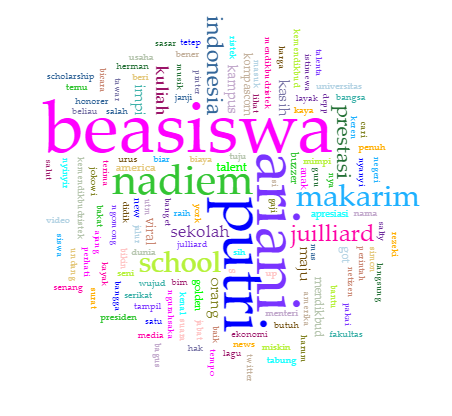

Links

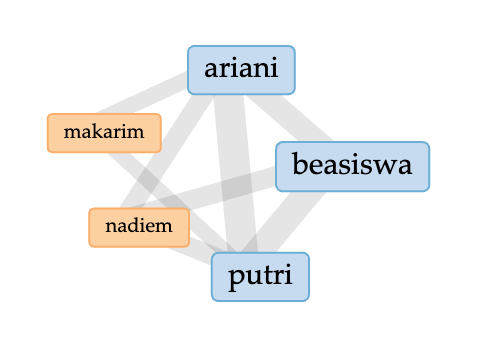

Word Tree

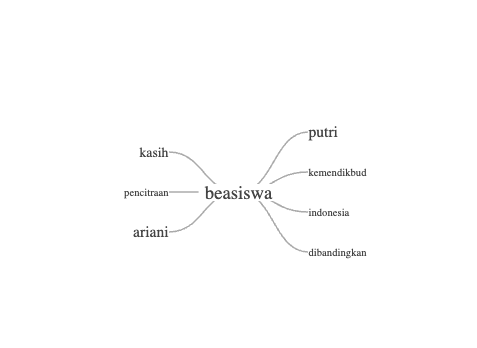

Trends

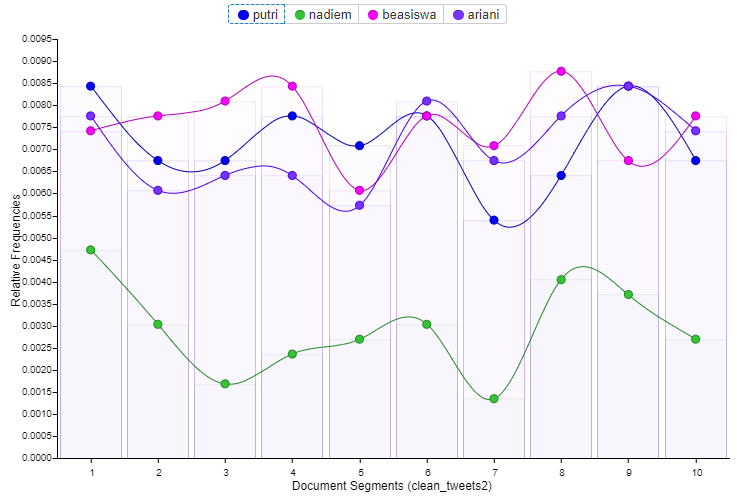

# Kesimpulan

Berdasarkan hasil visualisasi topik "Beasiswa Putri Ariani" menggunakan data yang ada pada Twitter, diperoleh kesimpulan bahwa kata kunci yang sering muncul adalah beasiswa, putri, ariani, dan nadiem.

Dari hasil tersebut, terbukti bahwa masyarakat Indonesia banyak yang menyuarakan pendapatnya terkait beasiswa yang diberikan Nadiem Makarim kepada Putri Ariani, baik yang pro atau kontra. Akan tetapi, mayoritas cenderung kontra terhadap penghargaan dari Nadiem tersebut.